In [1]:
import json

with open("data/math/math_train.json") as f:
    train_data = json.load(f)

with open("data/math/math_val.json") as f:
    val_data = json.load(f)

with open("data/math/math_test.json") as f:
    test_data = json.load(f)

In [2]:
train_steps = [len(item["steps"]) for item in train_data]
val_steps = [len(item["steps"]) for item in val_data]
test_steps = [len(item["steps"]) for item in test_data]

sum(train_steps)/len(train_steps), sum(val_steps)/len(val_steps), sum(test_steps)/len(test_steps)

(4.4524271844660195, 4.336134453781512, 4.376569037656904)

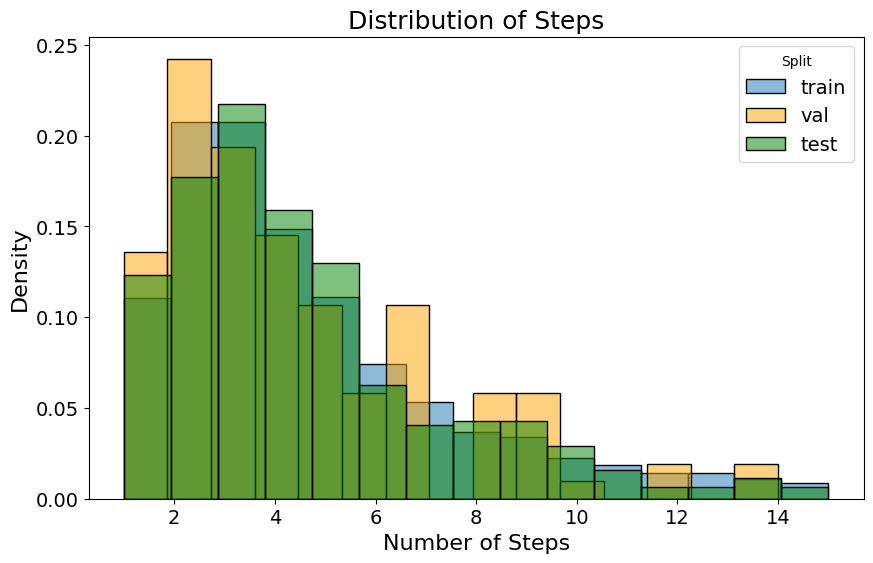

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(train_steps, bins=15, stat="density", label="train", alpha=0.5, ax=ax)
sns.histplot(val_steps, bins=15, stat="density", color="orange", label="val", alpha=0.5, ax=ax)
sns.histplot(test_steps, bins=15, stat="density", color="green", label="test", alpha=0.5, ax=ax)
ax.set_xlabel("Number of Steps", fontsize=16)
ax.set_ylabel("Density", fontsize=16)
ax.set_title("Distribution of Steps", fontsize=18)
ax.tick_params(axis='both', labelsize=14)
ax.legend(title="Split", fontsize=14)
# fig.savefig("figures/math_steps_dist.pdf", bbox_inches='tight')
plt.show()

In [4]:
train_step_diffs = [sum(item["steps_difficulties"])/len(item["steps_difficulties"]) for item in train_data]
val_step_diffs = [sum(item["steps_difficulties"])/len(item["steps_difficulties"]) for item in val_data]
test_step_diffs = [sum(item["steps_difficulties"])/len(item["steps_difficulties"]) for item in test_data]

sum(train_step_diffs)/len(train_step_diffs), sum(val_step_diffs)/len(val_step_diffs), sum(test_step_diffs)/len(test_step_diffs)

(2.236323427709406, 2.2027511004401763, 2.2139522532539413)

In [5]:
all_train_step_diffs = [d for item in train_data for d in item["steps_difficulties"]]
all_val_step_diffs = [d for item in val_data for d in item["steps_difficulties"]]
all_test_step_diffs = [d for item in test_data for d in item["steps_difficulties"]]

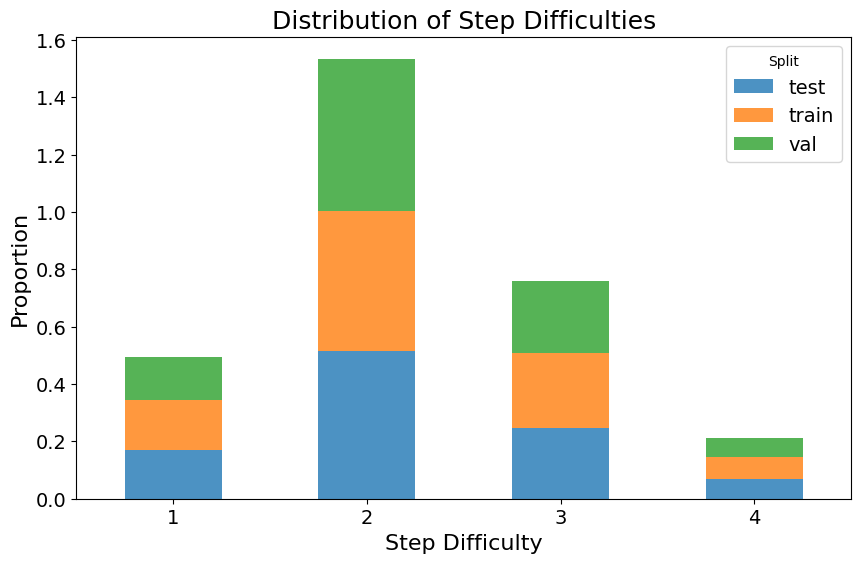

In [6]:
import pandas as pd

# Create a DataFrame with step difficulties and their source
df = pd.DataFrame({
    'step_difficulty': all_train_step_diffs + all_val_step_diffs + all_test_step_diffs,
    'split': ['train'] * len(all_train_step_diffs) + ['val'] * len(all_val_step_diffs) + ['test'] * len(all_test_step_diffs)
})

# Count occurrences for each difficulty and split
counts = df.groupby(['step_difficulty', 'split']).size().unstack(fill_value=0)
# Normalize to get density
counts = counts.div(counts.sum())

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))
counts.plot(kind='bar', stacked=True, ax=ax, alpha=0.8, color=['tab:blue', 'tab:orange', 'tab:green'])
ax.set_xlabel("Step Difficulty", fontsize=16)
ax.set_ylabel("Proportion", fontsize=16)
ax.set_title("Distribution of Step Difficulties", fontsize=18)
ax.legend(title="Split", fontsize=14)
ax.tick_params(axis='both', labelsize=14)
plt.xticks(rotation=0)
# fig.savefig("figures/math_step_diffs_dist.pdf", bbox_inches='tight')
plt.show()

In [8]:
import json

with open("/mnt/nlp/scratch/home/ismayilz/project-dycoder/models/math-dycoder-qwen2.5-0.5b-e5-with-diff/latents_epoch_5.json") as f:
    pred_latents = json.load(f)

test_pred_steps = [len(latent_pred["latents"]) for latent_pred in pred_latents]
test_pred_diffs = [num_latents for latent_pred in pred_latents for num_latents in latent_pred["latents"]]

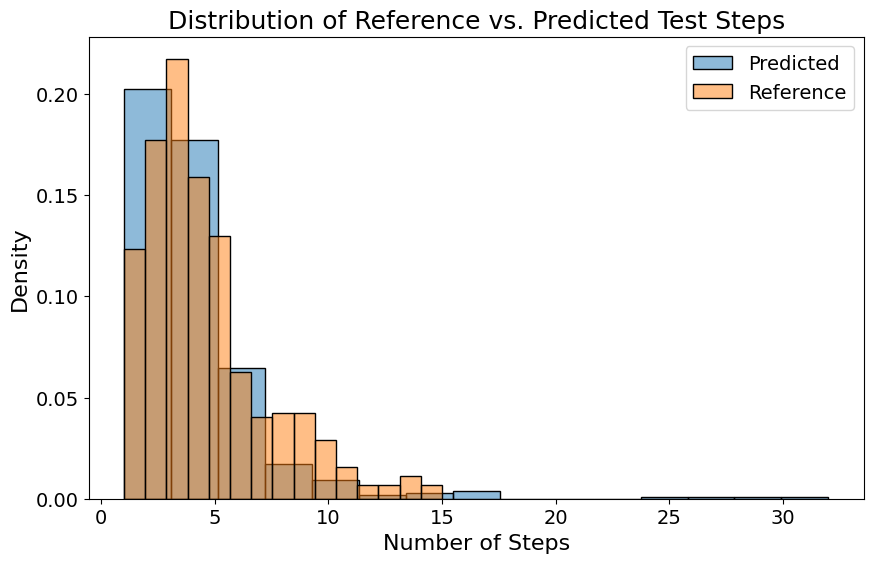

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(test_pred_steps, bins=15, stat="density", label="Predicted", color="tab:blue", alpha=0.5, ax=ax)
sns.histplot(test_steps, bins=15, stat="density", label="Reference", color="tab:orange", alpha=0.5, ax=ax)
ax.set_xlabel("Number of Steps", fontsize=16)
ax.set_ylabel("Density", fontsize=16)
ax.set_title("Distribution of Reference vs. Predicted Test Steps", fontsize=18)
ax.tick_params(axis='both', labelsize=14)
ax.legend(fontsize=14)
# fig.savefig("figures/math_pred_steps_dist.pdf", bbox_inches='tight')
plt.show()

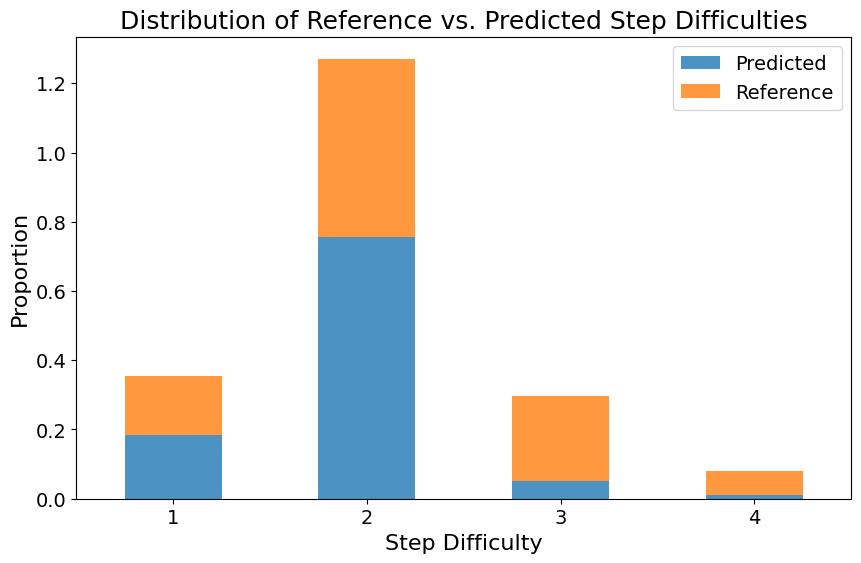

In [10]:
import pandas as pd

# Create a DataFrame with step difficulties and their source
df = pd.DataFrame({
    'step_difficulty': all_test_step_diffs + test_pred_diffs,
    'split': ['Reference'] * len(all_test_step_diffs) + ['Predicted'] * len(test_pred_diffs)
})

# Count occurrences for each difficulty and split
counts = df.groupby(['step_difficulty', 'split']).size().unstack(fill_value=0)
# Normalize to get density
counts = counts.div(counts.sum())

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))
counts.plot(kind='bar', stacked=True, ax=ax, alpha=0.8, color=['tab:blue', 'tab:orange'])
ax.set_xlabel("Step Difficulty", fontsize=16)
ax.set_ylabel("Proportion", fontsize=16)
ax.set_title("Distribution of Reference vs. Predicted Step Difficulties", fontsize=18)
ax.legend(fontsize=14)
ax.tick_params(axis='both', labelsize=14)
plt.xticks(rotation=0)
# fig.savefig("figures/math_pred_step_diffs_dist.pdf", bbox_inches='tight')
plt.show()